In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch import optim
from torch.utils.data import DataLoader
from tqdm import tqdm

from nn_functions import network


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
input_size = 784  # 28x28 pixels (not directly used in CNN)
num_classes = 10  # digits 0-9
learning_rate = 0.001
batch_size = 64
num_epochs = 10  # Reduced for demonstration purposes

In [4]:
#initialize network
model = network(in_channels=1, num_classes=num_classes).to(device)

In [ ]:
#accessing attributes

for name, lol in model.named_parameters():
    print(name, lol.shape, lol.requires_grad)

#access weights in a specific layer
weight = model.conv1.weight
print(weight[0].data)


state_dict = model.state_dict()
print("\nKeys in model.state_dict():")
for key in state_dict.keys():
    print(key)

fc2_bias_from_state_dict = state_dict['fc2.bias']
print(f"\nOutput layer bias from state_dict: {fc2_bias_from_state_dict}")

In [12]:
print(model.fc1.weight.data.shape)
print(model.conv1.weight.data.shape)

torch.Size([80, 800])
torch.Size([20, 1, 3, 3])


In [6]:
#loss function: computes cross entropy between input logits and target
criterion = nn.CrossEntropyLoss()

#updates model's weights
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [7]:
#load training and test data sets
train_dataset = datasets.MNIST(root="dataset/", download=True, train=True, transform=transforms.ToTensor())
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = datasets.MNIST(root="dataset/", download=True, train=False, transform=transforms.ToTensor())
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

1
tensor(5)


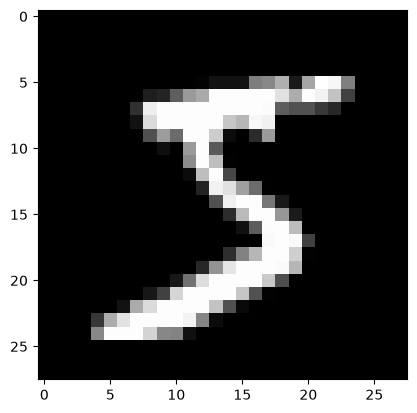

In [52]:
image, label = train_dataset[8]
print(label)

import matplotlib.pyplot as plt

#plt.imshow(image[0, :, :], cmap="gray")
plt.imshow(train_dataset.data[0], cmap="gray")
print(train_dataset.targets[0])

In [8]:
#train model

for epoch in range(num_epochs):
    print(f"Epoch [{epoch + 1}/{num_epochs}]")
    for batch_index, (data, targets) in enumerate(tqdm(train_loader)):
        # Move data and targets to the device (GPU/CPU)
        data = data.to(device)
        targets = targets.to(device)

        # Forward pass: compute the model output
        scores = model(data)
        loss = criterion(scores, targets)

        # Backward pass: compute the gradients
        optimizer.zero_grad()
        loss.backward()

        # Optimization step: update the model parameters
        optimizer.step()

Epoch [1/10]


100%|██████████| 938/938 [00:37<00:00, 24.90it/s]


Epoch [2/10]


100%|██████████| 938/938 [00:41<00:00, 22.37it/s]


Epoch [3/10]


...

100%|██████████| 938/938 [00:55<00:00, 16.88it/s]


Epoch [9/10]


100%|██████████| 938/938 [00:57<00:00, 16.44it/s]


Epoch [10/10]


100%|██████████| 938/938 [00:55<00:00, 16.87it/s]


In [9]:
def check_accuracy(loader, model):
    """
    Checks the accuracy of the model on the given dataset loader.

    Parameters:
        loader: DataLoader
            The DataLoader for the dataset to check accuracy on.
        model: nn.Module
            The neural network model.
    """
    if loader.dataset.train:
        print("Checking accuracy on training data")
    else:
        print("Checking accuracy on test data")

    num_correct = 0
    num_samples = 0
    model.eval()  # Set the model to evaluation mode

    with torch.no_grad():  # Disable gradient calculation
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            # Forward pass: compute the model output
            scores = model(x)
            _, predictions = scores.max(1)  # Get the index of the max log-probability
            num_correct += (predictions == y).sum()  # Count correct predictions
            num_samples += predictions.size(0)  # Count total samples

        # Calculate accuracy
        accuracy = float(num_correct) / float(num_samples) * 100
        print(f"Got {num_correct}/{num_samples} with accuracy {accuracy:.2f}%")
    
    model.train()  # Set the model back to training mode

In [10]:
# Final accuracy check on training and test sets
check_accuracy(train_loader, model)
check_accuracy(test_loader, model)

Checking accuracy on training data
Got 59705/60000 with accuracy 99.51%
Checking accuracy on test data
Got 9901/10000 with accuracy 99.01%


questions:

how are convolutional filters/kernels initialized? how are they updated?

In [ ]:
random_data = torch.rand((1, 1, 28, 28))
result = model(random_data)
print(result.max(1)[0])
print(torch.softmax(result, dim=1))


tensor(-0.4180, grad_fn=<SumBackward0>)
tensor([[2.3549e-03, 2.8588e-05, 2.4222e-01, 8.7953e-02, 2.1909e-06, 4.9438e-05,
         3.9029e-09, 8.0695e-03, 6.5839e-01, 9.3008e-04]],
       grad_fn=<SoftmaxBackward0>)
